# Portugal – PyPSA-Systemmodell (`02_modell.ipynb`)

Baut auf `01_potenzialanalyse.ipynb` auf: Regionen, Offshore-Zuordnung und
Kapazitätsfaktoren werden von dort geladen, nicht neu berechnet.

**Aufbau (schrittweise):**
1. Netzwerk-Grundgerüst (5 Busse, Zeitachse)
2. Kostendaten (technology-data, Annuitäten)
3. Bestehende Kraftwerke
4. Last
5. Erneuerbare Generatoren *(offen)*
6. Übertragungsleitungen *(offen)*
7. Speicher *(offen)*
8. Modellläufe + Sensitivitätsanalyse *(offen)*

## 1. Netzwerk-Grundgerüst

Wir laden die 5 Regionen aus `01_potenzialanalyse.ipynb` und legen für jede einen
Bus an — Koordinaten sind die Repräsentativpunkte (Aufgabenstellung: "For the
coordinates, take the representative points of the region shapes").

In [1]:
import pypsa
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt

# Regionen aus Notebook 1 laden (Geometrie + Repräsentativpunkte x/y)
regions = gpd.read_file("portugal_regions.gpkg")
print(regions[["region", "x", "y"]])

     region         x          y
0  Alentejo -7.823876  38.491093
1   Algarve -8.149914  37.255175
2    Centro -7.903626  39.973028
3    Lisboa -8.461003  38.297461
4     Norte -7.496424  41.577520


In [2]:
n = pypsa.Network()

# Bestandsanlagen sind später p_nom_extendable=False; ihre capital_cost geht damit als
# fixer Anteil in n.objective ein. Dieses Flag sorgt dafür, dass PyPSA diesen fixen
# Anteil korrekt mitzählt statt ihn stillschweigend wegzulassen.
pypsa.options.params.optimize.include_objective_constant = True

# Ein Bus je Region — carrier="AC" (Wechselstrom, PyPSA-Konvention)
n.add(
    "Bus",
    regions["region"],
    x=regions["x"].values,
    y=regions["y"].values,
    carrier="AC",
)
print(n.buses)

          v_nom type         x          y carrier unit location  v_mag_pu_set  \
name                                                                            
Alentejo    1.0      -7.823876  38.491093      AC                         1.0   
Algarve     1.0      -8.149914  37.255175      AC                         1.0   
Centro      1.0      -7.903626  39.973028      AC                         1.0   
Lisboa      1.0      -8.461003  38.297461      AC                         1.0   
Norte       1.0      -7.496424  41.577520      AC                         1.0   

          v_mag_pu_min  v_mag_pu_max control generator sub_network  
name                                                                
Alentejo           0.0           inf      PQ                        
Algarve            0.0           inf      PQ                        
Centro             0.0           inf      PQ                        
Lisboa             0.0           inf      PQ                        
Norte             

### Zeitachse

Ganzes Jahr 2013, 3-stündliche Auflösung (2.920 Zeitschritte statt 8.760) — spart
Rechenzeit bei der späteren Optimierung, bei vertretbarem Detailverlust.
`snapshot_weightings` gewichtet jeden Zeitschritt entsprechend mit dem Faktor 3, damit
Summen (Energie, Kosten) korrekt hochgerechnet werden.

**Wichtig:** diese Zelle nur hier, ein einziges Mal, ausführen. Ein erneutes
`n = pypsa.Network()` weiter unten würde Busse *und* Snapshots wieder zurücksetzen.

In [3]:
resolution = 3  # Stunden

snapshots = pd.date_range("2013-01-01", "2014-01-01", freq=f"{resolution}h", inclusive="left")
n.set_snapshots(snapshots)
n.snapshot_weightings.loc[:, :] = resolution

print("Zeitschritte:", len(n.snapshots))
print(n.snapshots[:3])
print(n.snapshot_weightings.head(2))

Zeitschritte: 2920
DatetimeIndex(['2013-01-01 00:00:00', '2013-01-01 03:00:00',
               '2013-01-01 06:00:00'],
              dtype='datetime64[us]', name='snapshot', freq='3h')
                     objective  stores  generators
snapshot                                          
2013-01-01 00:00:00        3.0     3.0         3.0
2013-01-01 03:00:00        3.0     3.0         3.0


Text(0.5, 1.0, 'Portugal – 5 Modellregionen als PyPSA-Busse')

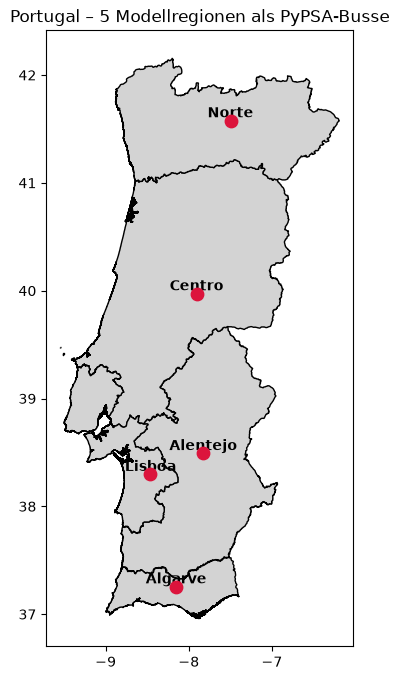

In [4]:
fig, ax = plt.subplots(figsize=(6, 8))
regions.plot(ax=ax, color="lightgrey", edgecolor="black")
for _, r in regions.iterrows():
    ax.scatter(r["x"], r["y"], s=80, color="crimson", zorder=5)
    ax.annotate(r["region"], (r["x"], r["y"]), ha="center", va="bottom", weight="bold")
ax.set_title("Portugal – 5 Modellregionen als PyPSA-Busse")

## 2. Kostendaten

Technologie-Annahmen (Investitionskosten, Wirkungsgrade, Lebensdauer) aus dem
[`technology-data`](https://github.com/PyPSA/technology-data)-Repository, Projektionsjahr
**2030** (konsistent mit dem GEGIS-Lastdatensatz, der ebenfalls auf 2030 projiziert).

Berechnung laut Aufgabenstellung:
- **Diskontrate:** 7 %
- **`marginal_cost`** (€/MWh) = Brennstoffkosten/Wirkungsgrad + variable O&M (VOM)
- **`capital_cost`** (€/MW/a) = annualisierte Investitionskosten + fixe O&M (FOM)

In [5]:
year = 2030
url = f"https://raw.githubusercontent.com/PyPSA/technology-data/master/outputs/costs_{year}.csv"
costs = pd.read_csv(url, index_col=[0, 1])

# Einheiten vereinheitlichen: alles auf /MW statt teils /kW (PyPSA-Konvention)
costs.loc[costs.unit.str.contains("/kW"), "value"] *= 1e3
costs.unit = costs.unit.str.replace("/kW", "/MW")

# Fehlende Werte mit sinnvollen Defaults auffüllen (z.B. Wind hat keine "fuel"-Kosten)
defaults = {
    "FOM": 0, "VOM": 0, "efficiency": 1, "fuel": 0, "investment": 0,
    "lifetime": 25, "CO2 intensity": 0, "discount rate": 0.07,   # 7 %, Aufgabenstellung
}
costs = costs.value.unstack().fillna(defaults)

# Gasturbinen (OCGT/CCGT) übernehmen Brennstoffkosten + CO2-Intensität von "gas"
costs.at["OCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["CCGT", "fuel"] = costs.at["gas", "fuel"]
costs.at["OCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]
costs.at["CCGT", "CO2 intensity"] = costs.at["gas", "CO2 intensity"]

print("Technologien geladen:", len(costs))

Technologien geladen: 300


### Annuität

Wandelt die einmalige Investitionssumme in eine jährliche Kostenrate um:

$$a(r, n) = \frac{r}{1-(1+r)^{-n}}$$

mit Diskontrate $r$ und Lebensdauer $n$. `pypsa.costs.annuity` berechnet das direkt.

In [6]:
from pypsa.costs import annuity

# marginal_cost: Brennstoff/Wirkungsgrad + variable O&M
costs["marginal_cost"] = costs["VOM"] + costs["fuel"] / costs["efficiency"]

# capital_cost: (Annuitätsfaktor + fixe O&M als Anteil der Investition) x Investition
annuity_factor = annuity(costs["discount rate"], costs["lifetime"])
costs["capital_cost"] = (annuity_factor + costs["FOM"] / 100) * costs["investment"]

# Sanity-Check mit den TATSAECHLICH vorhandenen Namen dieser technology-data-Version
check = ["solar", "onwind", "offwind", "offwind-float", "OCGT", "CCGT",
         "coal", "lignite", "oil", "nuclear", "hydro",
         "battery storage", "battery inverter", "electrolysis",
         "fuel cell", "hydrogen storage underground"]
vorhanden = [t for t in check if t in costs.index]
print("Nicht gefunden:", set(check) - set(vorhanden))
costs.loc[vorhanden, ["investment", "FOM", "efficiency", "lifetime",
                       "marginal_cost", "capital_cost"]].round(2)

Nicht gefunden: set()


parameter,investment,FOM,efficiency,lifetime,marginal_cost,capital_cost
technology,,,,,,
solar,683146.2,1.95,1.00,40.0,0.01,64560.14
onwind,1383305.9,1.22,1.00,30.0,1.80,128306.33
offwind,2114991.0,2.32,1.00,30.0,0.03,219475.58
offwind-float,2954736.3,1.15,1.00,20.0,0.00,312885.67
OCGT,581394.9,1.78,0.41,25.0,75.32,60235.72
CCGT,1108716.6,3.35,0.58,25.0,54.60,132274.90
coal,4812024.4,1.31,0.36,40.0,26.07,423983.33
lignite,4812024.4,1.31,0.33,40.0,28.17,423983.33
oil,458180.5,2.46,0.35,25.0,132.67,50601.69


**Hinweis:** Für Offshore-Wind verwenden wir `offwind-float` (schwimmend) statt des
generischen `offwind` (bodenfest) — konsistent mit der Flächeneignungsanalyse in
`01_potenzialanalyse.ipynb`. Netzanschlusskosten (Seekabel/Station) sind separat in
`technology-data` verfügbar, werden hier aber nicht einzeln modelliert; stattdessen
gilt für alle Übertragungsleitungen der Pauschalwert der Aufgabenstellung
(700 €/MW/km).

## 3. Bestehende Kraftwerke

Aufgabenstellung: "Add the fleet of existing conventional power plants to the network,
excluding wind and solar. […] aggregated to one representative generator per technology
and region." Wasserkraft wird separat und vereinfacht behandelt (konstantes `p_max_pu`
aus historischer Erzeugung ÷ installierter Leistung).

Erzeugungsjahr **2013** — konsistent mit dem ERA5-Wetterjahr (wichtig für Wasserkraft:
die Erzeugung hängt vom Niederschlag des jeweiligen Jahres ab).

Datengrundlage: Global Power Plant Database (WRI) — liegt im Aufgaben-ZIP als
**weltweiter**, nicht länderspezifisch zugeschnittener Datensatz vor.

In [7]:
# Globale Kraftwerksdatenbank laden (weltweit ~35.000 Zeilen, wir filtern gleich auf PT)
gppd = pd.read_csv(
    "assignment-4-data/global-power-plant-database/global_power_plant_database.csv",
    low_memory=False,   # unterdrückt eine harmlose DtypeWarning bei gemischten Metadaten-Spalten
)
print("Kraftwerke weltweit:", len(gppd))

Kraftwerke weltweit: 34936


In [8]:
# Nur Portugal, ohne Wind/Solar (die kommen separat aus 01_potenzialanalyse.ipynb)
pt_plants = gppd[(gppd["country"] == "PRT") &
                  (~gppd["primary_fuel"].isin(["Wind", "Solar"]))].copy()

# Jedem Kraftwerk seine Region zuordnen (räumlicher Join über lat/lon)
punkte = gpd.GeoDataFrame(
    pt_plants,
    geometry=gpd.points_from_xy(pt_plants["longitude"], pt_plants["latitude"]),
    crs=4326,
)
punkte = gpd.sjoin(punkte, regions[["region", "geometry"]], how="left", predicate="within")

# Kraftwerke ohne Regionszuordnung (erwartbar: Azoren/Madeira, nicht Teil unseres Modells)
ohne_region = punkte[punkte["region"].isna()]
print("Ohne Regionszuordnung (Azoren/Madeira):")
print(ohne_region[["name", "primary_fuel", "capacity_mw", "country_long"]])

pt_plants = punkte[punkte["region"].notna()].copy()
print(f"\n{len(pt_plants)} von {len(punkte)} Kraftwerken einer Festland-Region zugeordnet.")

Ohne Regionszuordnung (Azoren/Madeira):
                                                 name primary_fuel  \
18657                                    Além-Fazenda        Hydro   
18710                                         Calheta        Hydro   
18774                                Fajã da Nogueira        Hydro   
18775                                 Fajã dos Padres        Hydro   
18809                        Incineradora da Terceira        Waste   
18811                              Inverno da Calheta        Hydro   
18858  Meia Serra (Estação de Tratamento de Resíduos)        Waste   
18916                                   Pico Vermelho   Geothermal   
18951                                  Ribeira Grande   Geothermal   
18952                               Ribeira da Janela        Hydro   
18966                                  Santa Quitéria        Hydro   
18997                                   Serra de Água        Hydro   
19014                                      Socorri

In [9]:
jahr = 2013
pt_plants["generation_gwh"] = (
    pt_plants[f"generation_gwh_{jahr}"].fillna(pt_plants[f"estimated_generation_gwh_{jahr}"])
)
print("Kraftwerke ohne Erzeugungsdaten für", jahr, ":",
      pt_plants["generation_gwh"].isna().sum(), "von", len(pt_plants),
      "(betrifft praktisch nur kleine Wasserkraftwerke -> unterschätzt deren p_max_pu leicht, konservativ)")

# primary_fuel -> technology-data-Bezeichnung (fuer Grenz-/Kapitalkosten)
fuel_to_tech = {
    "Gas": "CCGT",          # Annahme: Kombikraftwerke (Portugals Gasflotte, grosse Einzelblöcke)
    "Coal": "coal",
    "Biomass": "biomass",
    "Waste": "waste CHP",
}
# Hydro wird separat behandelt (siehe unten)

unbekannt = set(pt_plants["primary_fuel"]) - set(fuel_to_tech) - {"Hydro"}
if unbekannt:
    print("WARNUNG - unbekannte Brennstofftypen, bitte Mapping ergaenzen:", unbekannt)
else:
    print("Alle Brennstofftypen zugeordnet.")

Kraftwerke ohne Erzeugungsdaten für 2013 : 47 von 159 (betrifft praktisch nur kleine Wasserkraftwerke -> unterschätzt deren p_max_pu leicht, konservativ)
Alle Brennstofftypen zugeordnet.


In [10]:
# Carrier-Komponenten anlegen (noetig fuer CO2-Bilanzierung und fuer n.statistics)
neue_carrier = ["CCGT", "coal", "biomass", "waste CHP", "hydro"]
n.add(
    "Carrier",
    neue_carrier,
    co2_emissions=[costs.at[c, "CO2 intensity"] for c in neue_carrier],
)
print("Carrier:", list(n.carriers.index))

Carrier: ['CCGT', 'coal', 'biomass', 'waste CHP', 'hydro']


In [11]:
# Thermische Kraftwerke: ein Generator je Region + Technologie (Bestandsanlage, fix)
thermal = pt_plants[pt_plants["primary_fuel"].isin(fuel_to_tech)].copy()
thermal["tech"] = thermal["primary_fuel"].map(fuel_to_tech)

agg_thermal = thermal.groupby(["region", "tech"]).agg(
    p_nom=("capacity_mw", "sum"), anzahl=("name", "count")
).reset_index()
print(agg_thermal)

for _, row in agg_thermal.iterrows():
    n.add(
        "Generator",
        f"{row['region']} {row['tech']}",
        bus=row["region"],
        carrier=row["tech"],
        p_nom=row["p_nom"],
        p_nom_extendable=False,          # Bestandsanlage: fix, nicht ausbaubar
        marginal_cost=costs.at[row["tech"], "marginal_cost"],
        capital_cost=costs.at[row["tech"], "capital_cost"],
        efficiency=costs.at[row["tech"], "efficiency"],
    )
print(f"\n{len(agg_thermal)} thermische Generatoren, {agg_thermal['p_nom'].sum():.0f} MW gesamt.")

     region       tech   p_nom  anzahl
0   Algarve  waste CHP     2.9       2
1    Centro       CCGT  1663.0       2
2    Centro    biomass   347.7      16
3    Centro       coal   682.0       1
4    Centro  waste CHP    15.7       7
5    Lisboa       CCGT  1176.0       1
6    Lisboa    biomass    66.4       2
7    Lisboa       coal  1296.0       1
8    Lisboa  waste CHP    62.2       7
9     Norte       CCGT   990.0       1
10    Norte    biomass    38.8       1
11    Norte  waste CHP    40.2       6

12 thermische Generatoren, 6381 MW gesamt.


In [12]:
# Wasserkraft: vereinfacht als Generator mit konstantem p_max_pu
# p_max_pu = historische Erzeugung [MWh] / (installierte Leistung [MW] * Stunden im Jahr)
hydro = pt_plants[pt_plants["primary_fuel"] == "Hydro"].copy()

agg_hydro = hydro.groupby("region").agg(
    p_nom=("capacity_mw", "sum"), erzeugung_gwh=("generation_gwh", "sum"),
    anzahl=("name", "count"),
).reset_index()

stunden_jahr = 8760
agg_hydro["p_max_pu"] = (agg_hydro["erzeugung_gwh"] * 1e3) / (agg_hydro["p_nom"] * stunden_jahr)
print(agg_hydro)

for _, row in agg_hydro.iterrows():
    n.add(
        "Generator",
        f"{row['region']} hydro",
        bus=row["region"],
        carrier="hydro",
        p_nom=row["p_nom"],
        p_nom_extendable=False,
        p_max_pu=row["p_max_pu"],        # konstanter Wert fuer alle Zeitschritte
        marginal_cost=costs.at["hydro", "marginal_cost"],
    )
print(f"\n{len(agg_hydro)} Wasserkraft-Generatoren, {agg_hydro['p_nom'].sum():.0f} MW gesamt.")

     region    p_nom  erzeugung_gwh  anzahl  p_max_pu
0  Alentejo   116.00         371.47      12  0.365563
1    Centro   576.95        1634.36      46  0.323374
2    Lisboa     3.00           8.98       2  0.341705
3     Norte  2011.40        5477.76      52  0.310885

4 Wasserkraft-Generatoren, 2707 MW gesamt.


## 4. Lastzeitreihe

GEGIS liefert die Last nur auf Länderebene. Verteilung auf die 5 Regionen nach
Bevölkerungsanteil (Aufgabenstellung). Bevölkerungszahlen: Volkszählung 2021,
Statistics Portugal / Eurostat NUTS-2 (alte Gliederung, konsistent mit unseren
GADM-Distrikten). Quelle: https://de.wikipedia.org/wiki/NUTS:PT

Kontrolle: Summe der 5 Regionen (9.857.593) = Portugal gesamt (10.344.802) minus
Azoren (236.440) minus Madeira (250.769) ✓

In [13]:
bevoelkerung = {
    "Norte": 3_587_074,
    "Centro": 2_227_567,
    "Lisboa": 2_870_770,
    "Alentejo": 704_707,
    "Algarve": 467_475,
}
regions["bevoelkerung"] = regions["region"].map(bevoelkerung)
regions["bev_anteil"] = regions["bevoelkerung"] / regions["bevoelkerung"].sum()
print(regions[["region", "bevoelkerung", "bev_anteil"]])
print("Summe Anteile:", regions["bev_anteil"].sum(), "(muss 1.0 sein)")

     region  bevoelkerung  bev_anteil
0  Alentejo        704707    0.071489
1   Algarve        467475    0.047423
2    Centro       2227567    0.225975
3    Lisboa       2870770    0.291224
4     Norte       3587074    0.363889
Summe Anteile: 0.9999999999999999 (muss 1.0 sein)


In [14]:
import os

# GEGIS-Ordner pruefen: einzelne globale CSV, kein Laender-Zuschnitt (wie bei der GPPD)
ordner_gegis = "assignment-4-data/gegis"
for wurzel, _, dateien in os.walk(ordner_gegis):
    for d in dateien:
        pfad = os.path.join(wurzel, d)
        print(f"{pfad:70s} {os.path.getsize(pfad)/1e6:8.2f} MB")

assignment-4-data/gegis/load.csv                                          22.43 MB


In [15]:
# Struktur pruefen, bevor wir Annahmen zu Format/Index treffen
load_preview = pd.read_csv(f"{ordner_gegis}/load.csv", nrows=5)
print("Spalten (Auszug):", list(load_preview.columns[:6]), "...")
print(load_preview.iloc[:, :4])

# Portugal-Spalte identifizieren
treffer = [c for c in load_preview.columns if c.upper() in ("PRT", "PT")]
print("\nPortugal-Spalte:", treffer)

Spalten (Auszug): ['time', 'AE', 'AL', 'AM', 'AO', 'AR'] ...
                  time            AE          AL          AM
0  2013-01-01 00:00:00  16140.623495  757.486559  667.467203
1  2013-01-01 01:00:00  17423.984557  732.913217  712.527478
2  2013-01-01 02:00:00  17975.465644  730.126405  818.316334
3  2013-01-01 03:00:00  19621.847025  731.702857  870.521907
4  2013-01-01 04:00:00  21415.787184  743.389539  862.778359

Portugal-Spalte: ['PT']


count    8760.000000
mean     6377.487631
std       722.306879
min      5033.358215
25%      5682.191479
50%      6448.986790
75%      6997.613692
max      8057.185707
Name: PT, dtype: float64


<Axes: title={'center': 'Portugal - Last 2013 (GEGIS-Projektion 2030) [MW]'}, xlabel='time'>

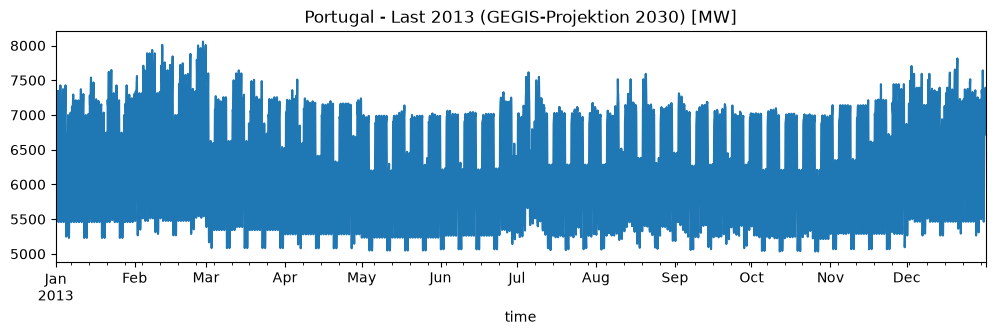

In [16]:
# Nur Zeit + Portugal-Spalte laden (die restlichen ~140 Laender brauchen wir nicht)
load_raw = pd.read_csv(f"{ordner_gegis}/load.csv", usecols=["time", "PT"])
load_raw["time"] = pd.to_datetime(load_raw["time"])
load_raw = load_raw.set_index("time")["PT"]

# Die Zeitstempel sind bereits auf 2013 datiert (GEGIS uebernimmt den stuendlichen
# Verlauf von 2013 als Muster, skaliert aber das Lastniveau auf die 2030-Projektion) -
# daher passt der Index direkt zu unseren ERA5-Snapshots, ohne Umrechnung.
print(load_raw.describe())   # Peak sollte plausibel bei Portugal ~8 GW liegen
load_raw.plot(figsize=(12, 3), title="Portugal - Last 2013 (GEGIS-Projektion 2030) [MW]")

Kontrolle - Summe der Regionen vs. Original (muessen uebereinstimmen):
count    2920.000000
mean     6377.487631
std       702.181117
min      5046.688481
25%      5716.539217
50%      6400.864044
75%      6995.906212
max      8026.706575
dtype: float64
count    2920.000000
mean     6377.487631
std       702.181117
min      5046.688481
25%      5716.539217
50%      6400.864044
75%      6995.906212
max      8026.706575
Name: PT, dtype: float64


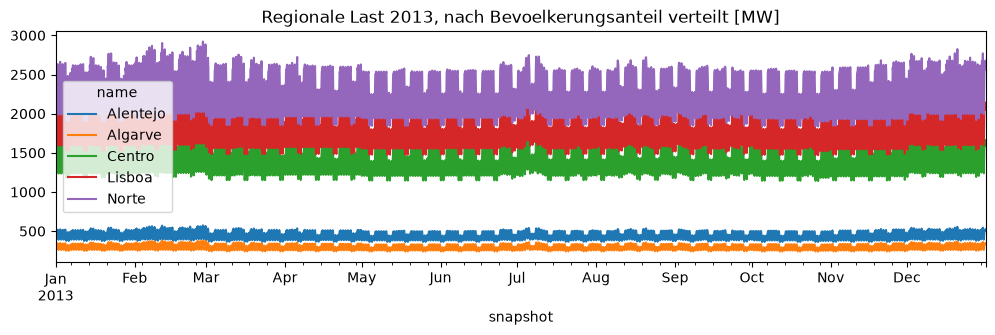

In [17]:
# Auf 3-stuendliche Modellaufloesung bringen (Mittelwert, da Leistungsgroesse)
load_pt = load_raw.resample(f"{resolution}h").mean()
load_pt = load_pt.reindex(n.snapshots)
assert load_pt.isna().sum() == 0, "Lastzeitreihe deckt nicht alle Snapshots ab!"

# Auf die 5 Regionen verteilen (Bevoelkerungsanteil) und als Load-Komponente einfuegen
for _, row in regions.iterrows():
    n.add("Load", row["region"], bus=row["region"], p_set=load_pt * row["bev_anteil"])

n.loads_t.p_set.plot(figsize=(12, 3), title="Regionale Last 2013, nach Bevoelkerungsanteil verteilt [MW]")

# Kontrolle: Summe aller Regionen muss der urspruenglichen Landeslast entsprechen
print("Kontrolle - Summe der Regionen vs. Original (muessen uebereinstimmen):")
print(n.loads_t.p_set.sum(axis=1).describe())
print(load_pt.describe())

## Zwischenstand

Netzwerk-Grundgerüst, Kostendaten, bestehende Kraftwerke und Last stehen. Kontroll-Zelle
für den schnellen Überblick (z.B. nach einem Kernel-Neustart):

In [19]:
print("Busse:       ", len(n.buses))
print("Zeitschritte:", len(n.snapshots))
print("Generatoren: ", len(n.generators))
print("Carrier:     ", len(n.carriers))
print("Loads:       ", len(n.loads))
# Erwartung an diesem Punkt: Busse=5, Zeitschritte=2920, Generatoren=16, Carrier=5, Loads=5

Busse:        5
Zeitschritte: 2920
Generatoren:  16
Carrier:      5
Loads:        5


## 5. Erneuerbare Generatoren

Aufgabenstellung: "Add one solar and on-/offshore wind generator per region […],
including the maximum installable potential (p_nom_max) and capacity factor time
series (p_max_pu). Assume a starting capacity of zero."

`p_max_pu` und `p_nom_max` kommen aus `01_potenzialanalyse.ipynb` (dort exportiert).
Anders als die Bestandskraftwerke sind diese Generatoren `p_nom_extendable=True` —
das Modell entscheidet selbst, wie viel gebaut wird.

In [20]:
# Kapazitätsfaktoren (stündlich, 2013) + installierbare Höchstleistung aus Notebook 1
p_max_pu_solar = pd.read_csv("p_max_pu_solar.csv", index_col=0, parse_dates=True)
p_max_pu_onshore = pd.read_csv("p_max_pu_onshore.csv", index_col=0, parse_dates=True)
p_max_pu_offshore = pd.read_csv("p_max_pu_offshore.csv", index_col=0, parse_dates=True)
p_nom_max = pd.read_csv("p_nom_max.csv", index_col=0)

# Auf 3-stündliche Modellauflösung resamplen (Mittelwert, wie bei der Last)
p_max_pu_solar = p_max_pu_solar.resample(f"{resolution}h").mean().reindex(n.snapshots)
p_max_pu_onshore = p_max_pu_onshore.resample(f"{resolution}h").mean().reindex(n.snapshots)
p_max_pu_offshore = p_max_pu_offshore.resample(f"{resolution}h").mean().reindex(n.snapshots)

for name, df in [("Solar", p_max_pu_solar), ("Onshore", p_max_pu_onshore), ("Offshore", p_max_pu_offshore)]:
    assert df.isna().sum().sum() == 0, f"{name}: fehlende Werte nach Angleichung!"
print(p_nom_max)

                 solar        onwind  offwind-float
region                                             
Alentejo  28489.500175  21114.871602    4173.757964
Algarve    5382.749812   2965.087642    4623.376003
Centro    32138.343628  15778.589806    6741.985894
Lisboa     5814.021793   1837.953881    7928.680477
Norte     14366.227774   6937.531144    9466.237506


In [21]:
# Carrier registrieren (CO2-Intensität 0 für erneuerbare Erzeugung)
erneuerbare_tech = {"solar": p_max_pu_solar, "onwind": p_max_pu_onshore, "offwind-float": p_max_pu_offshore}
n.add("Carrier", list(erneuerbare_tech.keys()), co2_emissions=0)

for tech, p_max_pu_df in erneuerbare_tech.items():
    for region in regions["region"]:
        if region not in p_max_pu_df.columns or region not in p_nom_max.index:
            continue  # z.B. Regionen ohne Offshore-Anteil
        n.add(
            "Generator",
            f"{region} {tech}",
            bus=region,
            carrier=tech,
            p_nom=0,                              # Startkapazität null (Aufgabenstellung)
            p_nom_extendable=True,                 # Modell entscheidet über Ausbau
            p_nom_max=p_nom_max.at[region, tech],
            p_max_pu=p_max_pu_df[region],
            capital_cost=costs.at[tech, "capital_cost"],
            marginal_cost=costs.at[tech, "marginal_cost"],
        )

print("Erneuerbare Generatoren:", len(n.generators) - 16, "neu hinzugefügt")
print("Generatoren gesamt:", len(n.generators))

Erneuerbare Generatoren: 15 neu hinzugefügt
Generatoren gesamt: 31


## 6. Übertragungsleitungen

Aufgabenstellung: bidirektionale Links zwischen Nachbarregionen, 700 €/MW/km,
Länge = 1,5 × Luftlinie zwischen den Repräsentativpunkten. Vereinfachung: keine
Verluste, keine Kirchhoff'schen Gesetze (reine Transportkapazität).

Nachbarschaft wird automatisch aus den Regionsgeometrien bestimmt (gemeinsame
Grenze), Distanz in EPSG:4087 (globale äquidistante Projektion, aus der
Kursvorbereitung `11-workshop-groupwork.ipynb`).

In [22]:
from itertools import combinations

# Nachbarschaft: gemeinsame Grenze (mit kleinem Puffer gegen Rand-Lücken aus GADM)
regions_m = regions.set_index("region").to_crs(3035)
nachbarn = [
    (a, b) for a, b in combinations(regions_m.index, 2)
    if regions_m.loc[a, "geometry"].buffer(500).intersects(regions_m.loc[b, "geometry"].buffer(500))
]
print("Nachbarschaften:", nachbarn)

# Luftlinien-Distanz zwischen Repräsentativpunkten, EPSG:4087 (global äquidistant)
punkte = gpd.GeoSeries(
    gpd.points_from_xy(regions["x"], regions["y"]), index=regions["region"], crs=regions.crs
).to_crs("EPSG:4087")

luftlinie_km = pd.DataFrame(
    {a: {b: punkte[a].distance(punkte[b]) / 1e3 for b in punkte.index} for a in punkte.index}
)
print(luftlinie_km.round(1))

Nachbarschaften: [('Alentejo', 'Algarve'), ('Alentejo', 'Centro'), ('Alentejo', 'Lisboa'), ('Centro', 'Lisboa'), ('Centro', 'Norte')]
          Alentejo  Algarve  Centro  Lisboa  Norte
Alentejo       0.0    142.3   165.2    74.1  345.5
Algarve      142.3      0.0   303.8   121.1  486.6
Centro       165.2    303.8     0.0   196.6  184.3
Lisboa        74.1    121.1   196.6     0.0  380.6
Norte        345.5    486.6   184.3   380.6    0.0


In [23]:
for a, b in nachbarn:
    laenge_km = luftlinie_km.at[a, b] * 1.5   # Aufgabenstellung: 1,5 x Luftlinie
    n.add(
        "Link",
        f"{a} - {b}",
        bus0=a,
        bus1=b,
        p_min_pu=-1,                  # bidirektional
        p_nom=0,
        p_nom_extendable=True,
        efficiency=1,                 # Vereinfachung: keine Verluste
        capital_cost=700 * laenge_km, # €/MW/a, 700 €/MW/km laut Aufgabenstellung
        carrier="AC",
    )

print(f"{len(nachbarn)} Übertragungsleitungen hinzugefügt.")
print(n.links[["bus0", "bus1", "p_nom_extendable", "capital_cost"]].round(0))

5 Übertragungsleitungen hinzugefügt.
                        bus0     bus1  p_nom_extendable  capital_cost
name                                                                 
Alentejo - Algarve  Alentejo  Algarve              True      149403.0
Alentejo - Centro   Alentejo   Centro              True      173467.0
Alentejo - Lisboa   Alentejo   Lisboa              True       77834.0
Centro - Lisboa       Centro   Lisboa              True      206401.0
Centro - Norte        Centro    Norte              True      193487.0


Text(0.5, 1.0, 'Übertragungsleitungen zwischen Nachbarregionen')

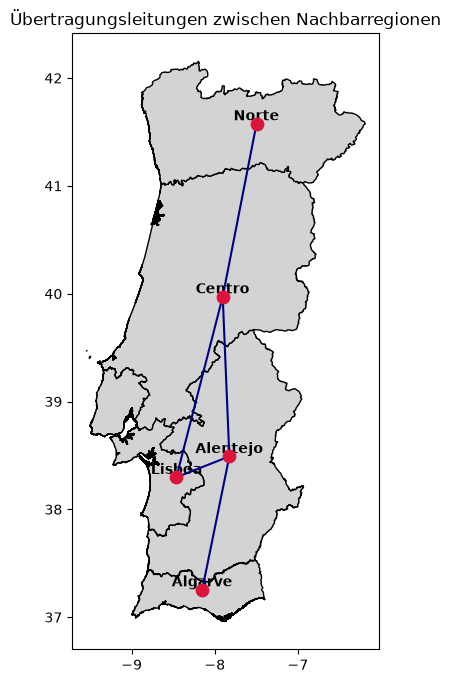

In [24]:
fig, ax = plt.subplots(figsize=(6, 8))
regions.plot(ax=ax, color="lightgrey", edgecolor="black")
for _, r in regions.iterrows():
    ax.scatter(r["x"], r["y"], s=80, color="crimson", zorder=5)
    ax.annotate(r["region"], (r["x"], r["y"]), ha="center", va="bottom", weight="bold")
for a, b in nachbarn:
    xa, ya = regions.set_index("region").loc[a, ["x", "y"]]
    xb, yb = regions.set_index("region").loc[b, ["x", "y"]]
    ax.plot([xa, xb], [ya, yb], color="navy", linewidth=1.5, zorder=4)
ax.set_title("Übertragungsleitungen zwischen Nachbarregionen")

## 7. Speicher

Batterie: 2h/4h/6h Energie-Leistungs-Verhältnis, je Region 3 unabhängige
Speicher-Optionen ("multiple units" laut Aufgabenstellung). Wasserstoff analog mit
168h/336h/672h. Kapitalkosten: Wechselrichter/Elektrolyse+Brennstoffzelle (leistungsbezogen,
unabhängig von max_hours) + Speichertank (energiebezogen, skaliert mit max_hours).

In [25]:
n.add("Carrier", ["battery storage", "hydrogen storage underground"], co2_emissions=0)

In [26]:
for region in regions["region"]:
    for h in [2, 4, 6]:
        n.add(
            "StorageUnit",
            f"{region} battery {h}h",
            bus=region,
            carrier="battery storage",
            max_hours=h,
            p_nom=0,
            p_nom_extendable=True,
            capital_cost=(costs.at["battery inverter", "capital_cost"]
                          + h * costs.at["battery storage", "capital_cost"]),
            efficiency_store=costs.at["battery inverter", "efficiency"],
            efficiency_dispatch=costs.at["battery inverter", "efficiency"],
        )
print("Batteriespeicher hinzugefügt:", 5 * 3)

Batteriespeicher hinzugefügt: 15


In [27]:
for region in regions["region"]:
    for h in [168, 336, 672]:
        capital_cost_h2 = (costs.at["electrolysis", "capital_cost"]
                            + costs.at["fuel cell", "capital_cost"]
                            + h * costs.at["hydrogen storage underground", "capital_cost"])
        n.add(
            "StorageUnit",
            f"{region} hydrogen {h}h",
            bus=region,
            carrier="hydrogen storage underground",
            max_hours=h,
            p_nom=0,
            p_nom_extendable=True,
            capital_cost=capital_cost_h2,
            efficiency_store=costs.at["electrolysis", "efficiency"],
            efficiency_dispatch=costs.at["fuel cell", "efficiency"],
        )
print("Wasserstoffspeicher hinzugefügt:", 5 * 3)

Wasserstoffspeicher hinzugefügt: 15


In [28]:
print("StorageUnits gesamt:", len(n.storage_units))
print(n.storage_units.groupby(["carrier"])["max_hours"].value_counts())

StorageUnits gesamt: 30
carrier                       max_hours
battery storage               2.0          5
                              4.0          5
                              6.0          5
hydrogen storage underground  168.0        5
                              336.0        5
                              672.0        5
Name: count, dtype: int64


## 8. Modellläufe

Zwei Läufe laut Aufgabenstellung: (1) ohne CO2-Limit, (2) mit 100 % CO2-Reduktion
(net-zero). Vorher: Kontrolle, welche Carrier überhaupt CO2-Emissionen haben.

In [30]:
print(n.carriers[["co2_emissions"]].sort_values("co2_emissions", ascending=False))

                              co2_emissions
name                                       
coal                                 0.3361
CCGT                                 0.1980
biomass                              0.0000
waste CHP                            0.0000
hydro                                0.0000
solar                                0.0000
onwind                               0.0000
offwind-float                        0.0000
battery storage                      0.0000
hydrogen storage underground         0.0000


In [31]:
n.optimize(solver_name="highs", log_to_console=False)

kosten_unlimited = n.objective / 1e9
kapazitaeten_unlimited = n.statistics.optimal_capacity().div(1e3)  # GW

print(f"Systemkosten (kein CO2-Limit): {kosten_unlimited:.2f} Mrd. €/a")
print(kapazitaeten_unlimited.round(2))

Index(['Alentejo', 'Algarve', 'Centro', 'Lisboa', 'Norte'], dtype='object', name='name')
Index(['Alentejo - Algarve', 'Alentejo - Centro', 'Alentejo - Lisboa',
       'Centro - Lisboa', 'Centro - Norte'],
      dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 8/8 [00:00<00:00, 118.82it/s]
INFO:linopy.io: Writing time: 1.39s
INFO:linopy.constants: Optimization successful: 
Status: ok
Termination condition: optimal
Solution: 367970 primals, 838105 duals
Objective: 2.16e+09
Solver model: available
Solver message: Optimal

INFO:pypsa.optimization.optimize:The shadow-prices of the constraints Generator-fix-p-lower, Generator-fix-p-upper, Generator-ext-p-lower, Generator-ext-p-upper, Link-ext-p-lower, Link-ext-p-upper, StorageUnit-ext-p_dispatch-lower, StorageUnit-ext-p_dispatch-upper, StorageUnit-ext-p_store-lower, Stora

Systemkosten (kein CO2-Limit): 2.16 Mrd. €/a
component    carrier        
Generator    CCGT               3.83
             biomass            0.45
             coal               1.98
             hydro              2.71
             offwind-float      0.10
             onwind             0.04
             solar              7.28
             waste CHP          0.12
Link         AC                 1.50
StorageUnit  battery storage    0.79
dtype: float64


In [32]:
emissionen_unlimited = (
    n.generators_t.p / n.generators.efficiency.replace(0, 1)
    * n.generators.carrier.map(n.carriers.co2_emissions)
).sum(axis=1)
co2_unlimited = (n.snapshot_weightings.generators @ emissionen_unlimited) / 1e6  # Mt
print(f"CO2-Emissionen (kein Limit): {co2_unlimited:.2f} Mt/a")

CO2-Emissionen (kein Limit): 20.22 Mt/a


In [33]:
n.add("GlobalConstraint", "CO2Limit", carrier_attribute="co2_emissions", sense="<=", constant=0)
n.optimize(solver_name="highs", log_to_console=False)

kosten_netzero = n.objective / 1e9
kapazitaeten_netzero = n.statistics.optimal_capacity().div(1e3)  # GW

print(f"Systemkosten (net-zero): {kosten_netzero:.2f} Mrd. €/a")
print(kapazitaeten_netzero.round(2))

Index(['Alentejo', 'Algarve', 'Centro', 'Lisboa', 'Norte'], dtype='object', name='name')
Index(['Alentejo - Algarve', 'Alentejo - Centro', 'Alentejo - Lisboa',
       'Centro - Lisboa', 'Centro - Norte'],
      dtype='object', name='name')
Index(['0', '1', '2', '3', '4'], dtype='object', name='name')
INFO:linopy.model: Solve problem using Highs solver
INFO:linopy.model:Solver options:
 - log_to_console: False
INFO:linopy.io:Writing objective.
Writing continuous variables.: 100%|██████████| 8/8 [00:00<00:00, 115.80it/s]
INFO:linopy.io: Writing time: 1.1s


In [ ]:
vergleich = pd.concat(
    {"ohne CO2-Limit": kapazitaeten_unlimited, "net-zero": kapazitaeten_netzero}, axis=1
).fillna(0).round(2)
print(vergleich)
print(f"\nSystemkosten: {kosten_unlimited:.2f} -> {kosten_netzero:.2f} Mrd. €/a "
      f"({(kosten_netzero/kosten_unlimited - 1)*100:+.1f} %)")